# Diabetes Prediction using Machine Learning

## 1. Project Overview
This notebook builds a binary classifier that predicts whether a patient is diabetic from eight diagnostic measurements in the **PIMA Indians Diabetes dataset**. The main model is a **linear Support Vector Machine (SVM)**.

> **Disclaimer:** This project is an educational machine-learning demonstration and is not a medically validated diagnostic tool.

## 2. Problem Statement
Given a patient's diagnostic measurements (glucose, BMI, age, etc.), predict whether the patient has diabetes (`Outcome = 1`) or not (`Outcome = 0`). This is a supervised binary classification problem.

## 3. Objectives
- Explore the dataset and check its data quality.
- Preprocess the data without data leakage (impute and scale using training data only).
- Train a linear SVM classifier.
- Evaluate it with accuracy, precision, recall, F1-score, confusion matrix and ROC-AUC.
- Build a small prediction function for a single new patient record.

## 4. Import Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 2
sns.set_theme(style="whitegrid")

## 5. Load Dataset
The dataset is stored in the repository at `data/diabetes.csv`. The path below is relative, so the notebook works whether it is started from the `notebooks/` folder or from the repository root.

In [2]:
DATA_PATH = Path("../data/diabetes.csv")
if not DATA_PATH.exists():          # notebook started from the repository root
    DATA_PATH = Path("data/diabetes.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 6. Dataset Overview
The dataset has 768 records, 8 input features and a binary target `Outcome` (0 = Non-Diabetic, 1 = Diabetic).

In [3]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
df.info()

Shape: (768, 9)
Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 7. Exploratory Data Analysis

### 7.1 Class distribution

                  count  percent
Outcome                         
Non-Diabetic (0)    500     65.1
Diabetic (1)        268     34.9


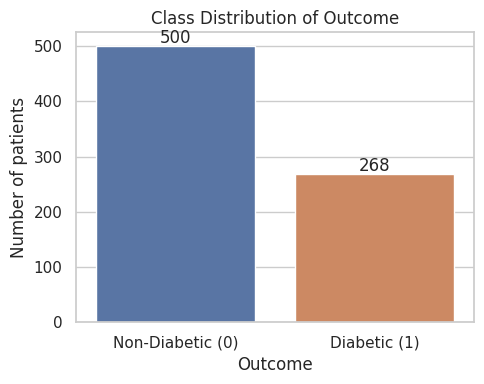

In [5]:
class_counts = df["Outcome"].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(1)
print(pd.DataFrame({"count": class_counts, "percent": class_pct}).rename(index={0: "Non-Diabetic (0)", 1: "Diabetic (1)"}))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Outcome", hue="Outcome", legend=False, ax=ax)
ax.set_xticks([0, 1], ["Non-Diabetic (0)", "Diabetic (1)"])
for i, n in enumerate(class_counts):
    ax.text(i, n + 5, str(n), ha="center")
ax.set_title("Class Distribution of Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel("Number of patients")
plt.tight_layout()
plt.show()

The classes are imbalanced (about 65% Non-Diabetic and 35% Diabetic). A model that always predicts *Non-Diabetic* would already reach about 65% accuracy, so accuracy alone is not enough and recall/F1 are also reported. The train-test split is stratified to keep this ratio in both sets.

### 7.2 Feature means by class

In [6]:
df.groupby("Outcome").mean().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.30,109.98,68.18,19.66,68.79,30.30,0.43,31.19
1,4.87,141.26,70.82,22.16,100.34,35.14,0.55,37.07


Diabetic patients have a noticeably higher average Glucose, BMI, Age and number of Pregnancies.

### 7.3 Feature distributions by class

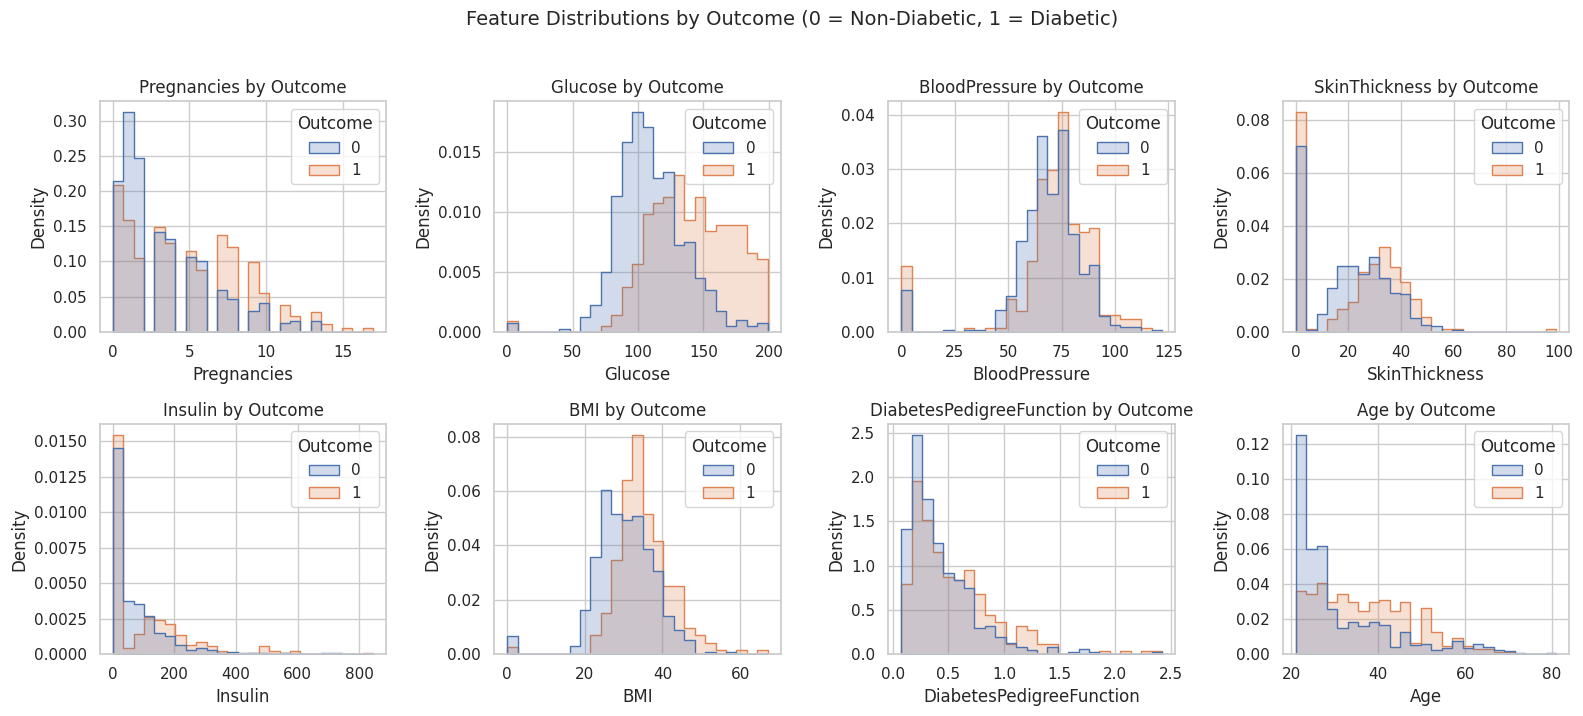

In [7]:
features = df.columns.drop("Outcome").tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(data=df, x=col, hue="Outcome", bins=25, stat="density",
                 common_norm=False, element="step", ax=ax)
    ax.set_title(f"{col} by Outcome")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
fig.suptitle("Feature Distributions by Outcome (0 = Non-Diabetic, 1 = Diabetic)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Glucose shows the clearest separation between the two classes. Several features (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) also have a spike at exactly **0**, which is physiologically impossible for these measurements. This is examined in Section 8.

### 7.4 Correlation heatmap
The five columns whose zeros are invalid (justified in Section 8) are treated as missing here, so the fake zeros do not distort the correlations. Correlations are computed pairwise on the available values.

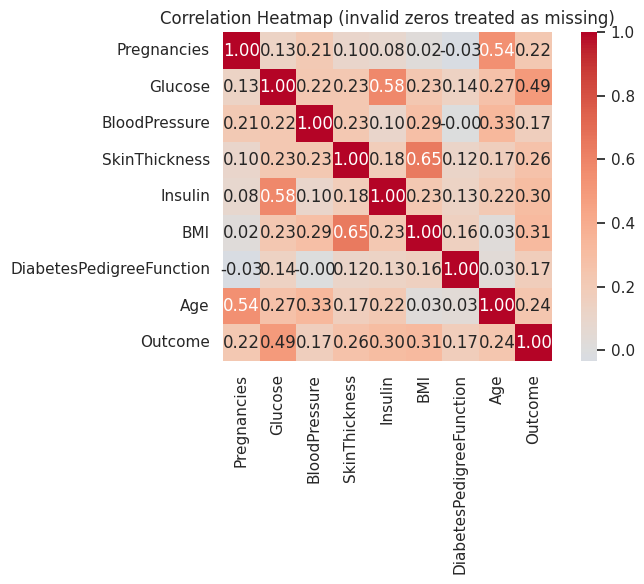

In [8]:
INVALID_ZERO_COLS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

corr = df.replace({col: {0: np.nan} for col in INVALID_ZERO_COLS}).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Correlation Heatmap (invalid zeros treated as missing)")
plt.tight_layout()
plt.show()

`Glucose` has the strongest correlation with `Outcome` (about 0.49), followed by `BMI` (0.31) and `Insulin` (0.30). Some input features are also correlated with each other, for example `SkinThickness` with `BMI` (0.65), `Insulin` with `Glucose` (0.58) and `Age` with `Pregnancies` (0.54).

## 8. Data Quality / Missing-Value Analysis
The dataset has no `NaN` entries, but missing measurements are encoded as **0**. A zero is not a valid value for:

- **Glucose**, **BloodPressure**, **BMI**: a living patient cannot have a value of 0.
- **SkinThickness**, **Insulin**: a skin-fold thickness or serum insulin of exactly 0 is not a real measurement.

`Pregnancies = 0` is a genuine value (never pregnant), and `DiabetesPedigreeFunction` and `Age` have no zeros, so these columns are left untouched.

NaN values: 0
               zero_count  zero_percent
Glucose                 5           0.7
BloodPressure          35           4.6
SkinThickness         227          29.6
Insulin               374          48.7
BMI                    11           1.4
Pregnancies == 0 (valid): 111


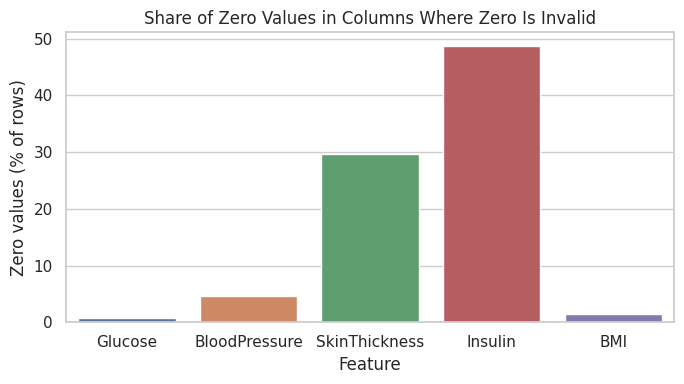

In [9]:
print("NaN values:", df.isna().sum().sum())

zero_counts = (df[INVALID_ZERO_COLS] == 0).sum()
zero_summary = pd.DataFrame({"zero_count": zero_counts,
                             "zero_percent": (zero_counts / len(df) * 100).round(1)})
print(zero_summary)
print("Pregnancies == 0 (valid):", (df["Pregnancies"] == 0).sum())

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=zero_summary.index, y=zero_summary["zero_percent"], hue=zero_summary.index,
            legend=False, ax=ax)
ax.set_title("Share of Zero Values in Columns Where Zero Is Invalid")
ax.set_xlabel("Feature")
ax.set_ylabel("Zero values (% of rows)")
plt.tight_layout()
plt.show()

**Treatment.** The invalid zeros in these five columns are converted to `NaN` and later imputed with the **median** (robust to the skewed distributions). To avoid data leakage:

1. Converting `0 → NaN` is a fixed rule that does not learn anything from the data, so it is applied to the whole feature table.
2. The **median values are learned from the training set only** and then applied to both the training and test sets.

`Insulin` (about half of the rows) and `SkinThickness` (about 30%) have a very large share of missing values, so median imputation there is a simple approximation (see Limitations).

## 9. Data Preprocessing

In [10]:
X = df.drop(columns="Outcome")
y = df["Outcome"]

X = X.copy()
X[INVALID_ZERO_COLS] = X[INVALID_ZERO_COLS].replace(0, np.nan)

print("Missing values after converting invalid zeros:")
print(X.isna().sum()[INVALID_ZERO_COLS])

Missing values after converting invalid zeros:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


## 10. Train-Test Split
The data is split **before** any statistic is learned (imputation medians, scaling mean/std). An 80/20 stratified split with a fixed `random_state` keeps the class ratio identical in both sets and makes the results reproducible.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Diabetic share  train: {:.3f}  test: {:.3f}".format(y_train.mean(), y_test.mean()))

Train: (614, 8) | Test: (154, 8)
Diabetic share  train: 0.349  test: 0.351


## 11. Feature Scaling
Missing values are imputed with the training-set median, then features are standardised with `StandardScaler` (important for SVMs). Both transformers are **fitted on the training data only** and then used to transform the test data and any new prediction input. `set_output(transform="pandas")` keeps the column names, so feature names stay consistent everywhere.

In [12]:
imputer = SimpleImputer(strategy="median").set_output(transform="pandas")
scaler = StandardScaler().set_output(transform="pandas")

X_train_imp = imputer.fit_transform(X_train)          # fit on train only
X_test_imp = imputer.transform(X_test)                # transform only

X_train_scaled = scaler.fit_transform(X_train_imp)    # fit on train only
X_test_scaled = scaler.transform(X_test_imp)          # transform only

print("Medians learned from the training set:")
print(pd.Series(imputer.statistics_, index=X.columns)[INVALID_ZERO_COLS])
print("\nRemaining missing values (train / test):",
      X_train_scaled.isna().sum().sum(), "/", X_test_scaled.isna().sum().sum())
X_train_scaled.head()

Medians learned from the training set:
Glucose          117.0
BloodPressure     72.0
SkinThickness     29.0
Insulin          123.5
BMI               32.4
dtype: float64



Remaining missing values (train / test): 0 / 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
619,-1.137965,-0.101441,-0.063818,-0.027163,-0.194143,-0.035742,-0.981597,-0.788523
329,0.640679,-0.559420,-0.226410,0.308634,-0.807057,-0.265392,-1.038238,0.318794
13,-0.841524,2.188450,-1.039368,-0.698757,7.784788,-0.365864,-0.215455,2.192716
476,-0.545084,-0.559420,0.586548,1.763756,0.551294,0.150848,0.717629,-0.362632
45,-1.137965,1.894035,-0.551593,1.092161,-0.194143,1.342155,4.241287,-0.703345


## 12. Model Training
The main model is a **linear SVM** (`SVC(kernel="linear")`). A **Logistic Regression** model is trained on exactly the same preprocessed data as a simple baseline for comparison.

In [13]:
svm_model = SVC(kernel="linear", random_state=RANDOM_STATE)
svm_model.fit(X_train_scaled, y_train)

logreg_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg_model.fit(X_train_scaled, y_train)
print("Both models trained.")

Both models trained.


## 13. Model Evaluation
ROC-AUC is computed from the SVM's `decision_function` scores. Precision, recall and F1 refer to the **Diabetic (1)** class.

In [14]:
def evaluate(model, X_data, y_data):
    pred = model.predict(X_data)
    scores = model.decision_function(X_data)
    return {
        "Accuracy": accuracy_score(y_data, pred),
        "Precision": precision_score(y_data, pred),
        "Recall": recall_score(y_data, pred),
        "F1-score": f1_score(y_data, pred),
        "ROC-AUC": roc_auc_score(y_data, scores),
    }

svm_results = pd.DataFrame({
    "Train": evaluate(svm_model, X_train_scaled, y_train),
    "Test": evaluate(svm_model, X_test_scaled, y_test),
}).T

print("Linear SVM (main model)")
svm_results.round(4)

Linear SVM (main model)


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Train,0.7785,0.7349,0.5701,0.6421,0.8496
Test,0.7727,0.7568,0.5185,0.6154,0.8200


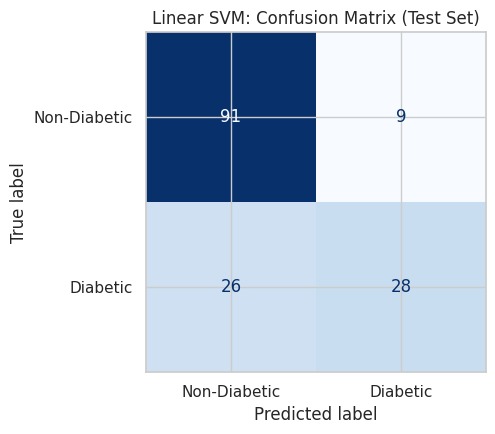

In [15]:
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_estimator(
    svm_model, X_test_scaled, y_test,
    display_labels=["Non-Diabetic", "Diabetic"], cmap="Blues", colorbar=False, ax=ax
)
ax.set_title("Linear SVM: Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

### Baseline comparison (test set)

In [16]:
comparison = pd.DataFrame({
    "Linear SVM": evaluate(svm_model, X_test_scaled, y_test),
    "Logistic Regression": evaluate(logreg_model, X_test_scaled, y_test),
}).T
comparison.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Linear SVM,0.7727,0.7568,0.5185,0.6154,0.8200
Logistic Regression,0.7403,0.6842,0.4815,0.5652,0.8141


## 14. Prediction on New Data
The input is a dictionary with the exact feature names. The same steps used for training are applied: invalid zeros become missing, then the **already-fitted** imputer and scaler transform the record, and the model predicts. Because the input is a DataFrame with the training column names and order, no feature-name warning occurs.

In [17]:
FEATURE_ORDER = X.columns.tolist()
print("Feature order:", FEATURE_ORDER)


def predict_patient(record):
    """Predict the class for one patient given as a dict of the 8 features."""
    new_X = pd.DataFrame([record], columns=FEATURE_ORDER)
    new_X[INVALID_ZERO_COLS] = new_X[INVALID_ZERO_COLS].replace(0, np.nan)
    new_X = scaler.transform(imputer.transform(new_X))
    label = int(svm_model.predict(new_X)[0])
    return label, "Diabetic" if label == 1 else "Non-Diabetic"


sample_patient = {
    "Pregnancies": 10,
    "Glucose": 139,
    "BloodPressure": 80,
    "SkinThickness": 0,
    "Insulin": 0,
    "BMI": 27.1,
    "DiabetesPedigreeFunction": 1.441,
    "Age": 57,
}

label, name = predict_patient(sample_patient)
print(f"Predicted class: {name} ({label})")

Feature order: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Predicted class: Diabetic (1)


`SkinThickness = 0` and `Insulin = 0` in this sample are treated as missing measurements and imputed with the training medians, consistent with the training pipeline. The output is a model prediction, not a medical diagnosis.

## 15. Conclusion
The linear SVM, trained on leak-free preprocessed data (invalid zeros treated as missing, median imputation and standardisation fitted on the training set only), gives these results on the held-out test set of 154 patients:

| Metric | Train | Test |
|---|---|---|
| Accuracy | 0.7785 | 0.7727 |
| Precision (Diabetic) | 0.7349 | 0.7568 |
| Recall (Diabetic) | 0.5701 | 0.5185 |
| F1-score (Diabetic) | 0.6421 | 0.6154 |
| ROC-AUC | 0.8496 | 0.8200 |

- The train and test accuracy are close, so there is no sign of strong overfitting.
- The test accuracy (77.3%) is above the 65% obtained by always predicting *Non-Diabetic*, but recall is only about 52%: the model misses roughly half of the diabetic patients in the test set (26 false negatives against 28 true positives), while it makes few false alarms (9 false positives).
- The linear SVM performed slightly better than the Logistic Regression baseline on every test metric.
- The original notebook fitted the scaler on the full dataset before splitting; correcting this and handling invalid zeros gave the same test accuracy but a slightly different train accuracy and ROC-AUC.

The model is a reasonable educational baseline, but it is not reliable enough for real medical use.

## 16. Limitations
- **Small dataset:** 768 records, and the test set has only 154 patients, so the metrics can change noticeably with a different split.
- **Limited population:** the PIMA dataset contains only female patients of PIMA Indian heritage aged 21 or older, so the model should not be assumed to generalise to other groups.
- **Missing data:** about half of the `Insulin` and 30% of the `SkinThickness` values are missing, and median imputation is only a simple approximation.
- **Class imbalance:** the classes are imbalanced and the default decision threshold favours the majority class, which limits recall for diabetic patients.
- **Single split:** results come from one stratified train-test split without cross-validation or hyperparameter tuning.
- **Not clinical:** the model is trained on a small public dataset and was not validated on clinical data.

## 17. Future Improvements
- Use stratified k-fold cross-validation for more reliable estimates.
- Tune hyperparameters (for example `C`) and try class weighting or threshold tuning to improve recall.
- Compare additional models such as Random Forest or Gradient Boosting.
- Try more advanced imputation methods (for example KNN or iterative imputation).
- Add model explainability (feature importance / coefficients).

## 18. Disclaimer
This project is an educational machine-learning demonstration and is not a medically validated diagnostic tool. It must not be used for medical diagnosis or treatment decisions. Consult a qualified healthcare professional for any health concern.